# Natural Language Processing Coursework

## Setup

In [1]:


import os
if not os.path.exists("../NLPLabs-2024"):
    !git clone -q https://github.com/CRLala/NLPLabs-2024.git


if not os.path.exists("../dontpatronizeme"):
    !git clone -q https://github.com/Perez-AlmendrosC/dontpatronizeme.git

    
pcl_tsv_path = "../NLPLabs-2024/Dont_Patronize_Me_Trainingset/dontpatronizeme_pcl.tsv"
train_split_path = "../dontpatronizeme/semeval-2022/practice splits/train_semeval_parids-labels.csv"
dev_split_path   = "../dontpatronizeme/semeval-2022/practice splits/dev_semeval_parids-labels.csv"


In [2]:
import os
from pathlib import Path
import re
import csv
import numpy as np
from collections import Counter
import pandas as pd
import matplotlib.pyplot as plt
from transformers import AutoTokenizer
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_selection import chi2

In [3]:
from huggingface_hub import login
import os
# Option 1: token from environment variable (recommended)
token = os.getenv("HF_TOKEN")
if token is not None:
    login(token=token)
else:
    # Interactive login (will prompt in notebook / terminal)
    login()

In [4]:
rows=[]
with open(pcl_tsv_path) as f:
    for line in f.readlines()[4:]:
        par_id=line.strip().split('\t')[0]
        art_id = line.strip().split('\t')[1]
        keyword=line.strip().split('\t')[2]
        country=line.strip().split('\t')[3]
        t=line.strip().split('\t')[4]#.lower()
        l=line.strip().split('\t')[-1]
        if l=='0' or l=='1':
            lbin=0
        else:
            lbin=1
        rows.append(
            {'par_id':int(par_id),
            'doc_id':art_id,
            'keyword':keyword,
            'country':country,
            'text':t, 
            'label':lbin, 
            'orig_label':int(l)
            }
        )
df=pd.DataFrame(rows, columns=['par_id', 'doc_id', 'keyword', 'country', 'text', 'label', 'orig_label'])
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10469 entries, 0 to 10468
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   par_id      10469 non-null  int64
 1   doc_id      10469 non-null  str  
 2   keyword     10469 non-null  str  
 3   country     10469 non-null  str  
 4   text        10469 non-null  str  
 5   label       10469 non-null  int64
 6   orig_label  10469 non-null  int64
dtypes: int64(3), str(4)
memory usage: 3.4 MB


In [5]:
import ast
import numpy as np
import pandas as pd


train_split = pd.read_csv(train_split_path)
dev_split   = pd.read_csv(dev_split_path)

# Parse 7-dim multi-hot label vectors
def parse_label_vec(x):
    v = ast.literal_eval(x) if isinstance(x, str) else x
    if not isinstance(v, list) or len(v) != 7:
        raise ValueError(f"Expected 7-dim list, got: {x}")
    # float for BCEWithLogitsLoss in multi-label training
    return [float(t) for t in v]

train_split["par_id"] = train_split["par_id"].astype(int)
dev_split["par_id"]   = dev_split["par_id"].astype(int)
train_split["label_vec"] = train_split["label"].apply(parse_label_vec)
dev_split["label_vec"]   = dev_split["label"].apply(parse_label_vec)

# Build train/dev dataframes based on par_id
train_ids = set(train_split["par_id"].tolist())
dev_ids   = set(dev_split["par_id"].tolist())

df_train = df[df["par_id"].isin(train_ids)].copy().reset_index(drop=True)
df_dev   = df[df["par_id"].isin(dev_ids)].copy().reset_index(drop=True)

# Attach label_vec
train_map = dict(zip(train_split["par_id"], train_split["label_vec"]))
dev_map   = dict(zip(dev_split["par_id"], dev_split["label_vec"]))

df_train["label_vec"] = df_train["par_id"].map(train_map)
df_dev["label_vec"]   = df_dev["par_id"].map(dev_map)

# Sanity checks
assert df_train["label_vec"].notna().all(), "Some train rows missing label_vec (par_id mismatch)"
assert df_dev["label_vec"].notna().all(), "Some dev rows missing label_vec (par_id mismatch)"
assert set(df_train["label"].unique()).issubset({0, 1}), "Binary label column must be 0/1"
assert set(df_dev["label"].unique()).issubset({0, 1}), "Binary label column must be 0/1"

print("Train:", df_train.shape, "pos_rate:", df_train["label"].mean())
print("Dev:  ", df_dev.shape,   "pos_rate:", df_dev["label"].mean())

Train: (8375, 8) pos_rate: 0.09480597014925374
Dev:   (2094, 8) pos_rate: 0.09503342884431709


In [ ]:
import numpy as np
import pandas as pd
import random
import torch

from sklearn.metrics import average_precision_score, f1_score

TEST_TSV = "../dontpatronizeme/semeval-2022/TEST/task4_test.tsv"

MODEL_NAME = "roberta-base"
MAX_LEN = 256

VAL_FRAC = 0.10
SEEDS = [42, 43, 44]
TASK1_GRID = [
    (1.5e-5, 3),
    (2.0e-5, 3),
    (2.0e-5, 4),
    (2.5e-5, 4),
    (3.0e-5, 4),
]
POS_WEIGHT_MULTIPLIERS = [0.35, 0.50, 0.75, 1.00]
USE_GROUP_BALANCE = True
GROUP_BALANCE_COLS = ("keyword", "label")
USE_TASK2_WARM_START = False
NORMALIZE_TEXT = False

def set_seed(seed: int):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

def stratified_split(df: pd.DataFrame, label_col="label", val_frac=0.1, seed=42):
    rng = np.random.default_rng(seed)
    pos_idx = df.index[df[label_col] == 1].to_numpy().copy()
    neg_idx = df.index[df[label_col] == 0].to_numpy().copy()
    rng.shuffle(pos_idx)
    rng.shuffle(neg_idx)

    npos = max(1, int(round(len(pos_idx) * val_frac))) if len(pos_idx) else 0
    nneg = max(1, int(round(len(neg_idx) * val_frac))) if len(neg_idx) else 0

    val_idx = np.concatenate([pos_idx[:npos], neg_idx[:nneg]])
    train_idx = np.setdiff1d(df.index.to_numpy(), val_idx, assume_unique=False)

    return df.loc[train_idx].reset_index(drop=True), df.loc[val_idx].reset_index(drop=True)

In [7]:

def reorder_by_parid(df: pd.DataFrame, parids_in_order):
    order = {int(pid): i for i, pid in enumerate(parids_in_order)}
    out = df[df["par_id"].isin(order.keys())].copy()
    out["__o"] = out["par_id"].map(order)
    out = out.sort_values("__o").drop(columns="__o").reset_index(drop=True)
    return out

# 4. Model

In [8]:
from torch import nn
from torch.utils.data import DataLoader, WeightedRandomSampler
from transformers import Trainer

from sklearn.metrics import average_precision_score, f1_score, precision_score, recall_score


def normalize_text(text):
    if not isinstance(text, str):
        return text
    text = (
        text.replace("\u2018", "'")
            .replace("\u2019", "'")
            .replace("\u201c", '"')
            .replace("\u201d", '"')
            .replace("\u2013", "-")
            .replace("\u2014", "-")
            .replace("\u2212", "-")
    )
    text = re.sub(r"\s+", " ", text).strip()
    return text

def make_class_weights(df: pd.DataFrame, pos_multiplier: float = 1.0):
    neg = int((df["label"] == 0).sum())
    pos = int((df["label"] == 1).sum())
    base_w_pos = neg / max(pos, 1)
    tuned_w_pos = float(base_w_pos * pos_multiplier)
    class_weights = torch.tensor([1.0, tuned_w_pos], dtype=torch.float32)
    return class_weights, base_w_pos, tuned_w_pos


def group_invfreq_weights(df: pd.DataFrame, cols=("keyword", "label")):
    if not all(col in df.columns for col in cols):
        return None

    group_keys = df.loc[:, list(cols)].astype(str).agg("||".join, axis=1)
    freq = group_keys.value_counts().to_dict()

    w = group_keys.map(lambda k: 1.0 / float(freq.get(k, 1))).to_numpy(dtype=np.float64)
    w = w / np.mean(w)
    return w
    
class StripKeysCollator:
    def __init__(self, base_collator, drop=("keyword",)):
        self.base = base_collator
        self.drop = set(drop)

    def __call__(self, features):
        for f in features:
            for k in list(f.keys()):
                if k in self.drop:
                    f.pop(k, None)
        return self.base(features)


class WeightedCEKeywordTrainer(Trainer):
    def __init__(self, class_weights: torch.Tensor, sampler_weights=None, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self.class_weights_cpu = class_weights.detach().cpu()
        self.loss_fct = None
        self.sampler_weights = sampler_weights

    def compute_loss(self, model, inputs, return_outputs=False, num_items_in_batch=None, **kwargs):
        labels = inputs.pop("labels")
        if isinstance(labels, torch.Tensor):
            labels = labels.long()

        outputs = model(**inputs)
        logits = outputs.logits

        if self.loss_fct is None or self.loss_fct.weight.device != logits.device:
            w = self.class_weights_cpu.to(logits.device)
            self.loss_fct = nn.CrossEntropyLoss(weight=w)

        loss = self.loss_fct(logits, labels)
        return (loss, outputs) if return_outputs else loss

    def get_train_dataloader(self):
        if self.sampler_weights is None:
            return super().get_train_dataloader()

        sampler = WeightedRandomSampler(
            weights=torch.as_tensor(self.sampler_weights, dtype=torch.double),
            num_samples=len(self.sampler_weights),
            replacement=True,
        )

        return DataLoader(
            self.train_dataset,
            batch_size=self.args.train_batch_size,
            sampler=sampler,
            collate_fn=self.data_collator,
            num_workers=self.args.dataloader_num_workers,
            pin_memory=self.args.dataloader_pin_memory,
        )


def compute_metrics_task1(eval_pred):
    logits, labels = eval_pred
    probs = torch.softmax(torch.tensor(logits), dim=-1)[:, 1].numpy()
    y = labels.astype(int)
    pred05 = (probs >= 0.5).astype(int)
    return {
        "auprc": float(average_precision_score(y, probs)),
        "f1@0.5": float(f1_score(y, pred05, zero_division=0)),
        "precision@0.5": float(precision_score(y, pred05, zero_division=0)),
        "recall@0.5": float(recall_score(y, pred05, zero_division=0)),
    }

def best_f1_threshold(y_true: np.ndarray, probs: np.ndarray):
    probs = np.asarray(probs, dtype=np.float64)
    candidates = np.unique(np.concatenate(([0.0, 1.0], np.clip(probs, 0.0, 1.0))))
    best_t, best_f1 = 0.5, -1.0

    for t in candidates:
        f1 = f1_score(y_true, (probs >= t).astype(int), zero_division=0)
        if f1 > best_f1:
            best_f1 = float(f1)
            best_t = float(t)

    return best_t, best_f1

In [9]:
from datasets import Dataset
from transformers import (
    AutoTokenizer, AutoModelForSequenceClassification,
    DataCollatorWithPadding, TrainingArguments
)

from torch.utils.data import DataLoader

device = "cuda" if torch.cuda.is_available() else "cpu"

use_bf16 = torch.cuda.is_available() and torch.cuda.is_bf16_supported()
use_fp16 = torch.cuda.is_available() and (not use_bf16)
model_dtype = torch.bfloat16 if use_bf16 else (torch.float16 if use_fp16 else torch.float32)

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, use_fast=True)
base_collator = DataCollatorWithPadding(
    tokenizer=tokenizer,
    pad_to_multiple_of=8 if device == "cuda" else None
)

def make_task2_ds(df_, max_len=256):
    ds = Dataset.from_pandas(df_[["text", "label_vec"]], preserve_index=False)

    def tok(b):
        enc = tokenizer(b["text"], truncation=True, max_length=max_len)
        enc["labels"] = b["label_vec"]
        return enc

    return ds.map(tok, batched=True, remove_columns=["text", "label_vec"])

def make_task1_ds(df_, keep_keyword: bool, max_len=256):
    cols = ["text", "label"] + (["keyword"] if keep_keyword else [])
    ds = Dataset.from_pandas(df_[cols], preserve_index=False)

    def tok(b):
        enc = tokenizer(b["text"], truncation=True, max_length=max_len)
        enc["labels"] = b["label"]
        if keep_keyword and "keyword" in b:
            enc["keyword"] = b["keyword"]
        return enc

    remove_cols = ["text", "label"] + (["keyword"] if keep_keyword else [])
    return ds.map(tok, batched=True, remove_columns=remove_cols)

def make_infer_ds(df_, max_len=256):
    ds = Dataset.from_pandas(df_[["text"]], preserve_index=False)

    def tok(b):
        return tokenizer(b["text"], truncation=True, max_length=max_len)

    return ds.map(tok, batched=True, remove_columns=["text"])

@torch.no_grad()
def predict_probs_pos(model, infer_ds, batch_size=16):
    model.eval()
    dl = DataLoader(infer_ds, batch_size=batch_size, shuffle=False, collate_fn=base_collator)
    probs = []

    for batch in dl:
        batch = {k: v.to(model.device) for k, v in batch.items()}
        logits = model(**batch).logits
        p = torch.softmax(logits, dim=-1)[:, 1]
        probs.append(p.detach().cpu())

    return torch.cat(probs).numpy()

def train_one_seed(seed: int, df_train_inner, df_val_inner):
    set_seed(seed)
    if USE_TASK2_WARM_START:
        task2_out = f"checkpoints/task2_seed{seed}"
        model_t2 = AutoModelForSequenceClassification.from_pretrained(
            MODEL_NAME, num_labels=7, problem_type="multi_label_classification"
        ).to(device)

        train_t2 = make_task2_ds(df_train_inner, MAX_LEN)

        args_t2 = TrainingArguments(
            output_dir=task2_out,
            seed=seed,
            num_train_epochs=3,
            learning_rate=2e-5,
            weight_decay=0.01,
            warmup_ratio=0.06,
            eval_strategy="no",
            save_strategy="no",
            report_to="none",
            per_device_train_batch_size=8,
            per_device_eval_batch_size=16,
            gradient_accumulation_steps=2,
            fp16=use_fp16,
            bf16=use_bf16,
            gradient_checkpointing=False,
            eval_accumulation_steps=16,
        )

        t2 = Trainer(
            model=model_t2,
            args=args_t2,
            train_dataset=train_t2,
            data_collator=base_collator,
        )
        t2.train()

        try:
            t2.model.save_pretrained(task2_out, safe_serialization=True)
        except TypeError:
            t2.model.save_pretrained(task2_out)
        tokenizer.save_pretrained(task2_out)

        task1_init_source = task2_out
        task1_init_kwargs = {"num_labels": 2, "ignore_mismatched_sizes": True}
    else:
        task1_init_source = MODEL_NAME
        task1_init_kwargs = {"num_labels": 2}

    best = None

    for pos_multiplier in POS_WEIGHT_MULTIPLIERS:
        class_weights, base_w_pos, tuned_w_pos = make_class_weights(df_train_inner, pos_multiplier)

        for lr, epochs in TASK1_GRID:
            run_dir = f"checkpoints/task1_seed{seed}_w{pos_multiplier}_lr{lr}_ep{epochs}"

            train_t1 = make_task1_ds(df_train_inner, keep_keyword=True,  max_len=MAX_LEN)
            val_t1   = make_task1_ds(df_val_inner,   keep_keyword=False, max_len=MAX_LEN)

            sampler_w = None
            if USE_GROUP_BALANCE:
                sampler_w = group_invfreq_weights(df_train_inner, cols=GROUP_BALANCE_COLS)

            model_t1 = AutoModelForSequenceClassification.from_pretrained(
                task1_init_source, **task1_init_kwargs
            ).to(device)

            args_t1 = TrainingArguments(
                output_dir=run_dir,
                seed=seed,
                num_train_epochs=epochs,
                learning_rate=lr,
                weight_decay=0.01,
                warmup_ratio=0.06,
                eval_strategy="no",
                save_strategy="no",
                remove_unused_columns=False,
                report_to="none",
                per_device_train_batch_size=8,
                per_device_eval_batch_size=16,
                gradient_accumulation_steps=2,
                fp16=use_fp16,
                bf16=use_bf16,
                gradient_checkpointing=False,
                eval_accumulation_steps=16,
            )

            t1 = WeightedCEKeywordTrainer(
                class_weights=class_weights,
                sampler_weights=sampler_w,
                model=model_t1,
                args=args_t1,
                train_dataset=train_t1,
                data_collator=StripKeysCollator(base_collator, drop=("keyword",)),
            )
            t1.train()

            try:
                t1.model.save_pretrained(run_dir, safe_serialization=True)
            except TypeError:
                t1.model.save_pretrained(run_dir)
            tokenizer.save_pretrained(run_dir)

            pred = t1.predict(val_t1)
            probs_val = torch.softmax(torch.tensor(pred.predictions), dim=-1)[:, 1].numpy()
            y_val = pred.label_ids.astype(int)

            best_t_run, best_f1_run = best_f1_threshold(y_val, probs_val)

            auprc = float(average_precision_score(y_val, probs_val))

            is_better = (
                (best is None)
                or (best_f1_run > best["best_f1"] + 1e-12)
                or (
                    abs(best_f1_run - best["best_f1"]) <= 1e-12
                    and auprc > best["auprc"] + 1e-12
                )
            )

            if is_better:
                best = {
                    "dir": run_dir,
                    "probs": probs_val,
                    "y": y_val,
                    "best_threshold": best_t_run,
                    "best_f1": best_f1_run,
                    "auprc": auprc,
                    "lr": lr,
                    "epochs": epochs,
                    "pos_multiplier": pos_multiplier,
                    "base_w_pos": base_w_pos,
                    "tuned_w_pos": tuned_w_pos,
                }

    return (
        best["dir"],
        best["probs"],
        best["y"],
        best["best_f1"],
        best["auprc"],
        best["lr"],
        best["epochs"],
        best["pos_multiplier"],
        best["best_threshold"],
        best["tuned_w_pos"],
    )


In [10]:
def refit_one_seed(seed: int, lr: float, epochs: int, pos_multiplier: float):
    set_seed(seed)

    class_weights, base_w_pos, tuned_w_pos = make_class_weights(df_train, pos_multiplier)

    if USE_TASK2_WARM_START:
        task2_out = f"checkpoints/task2_refit_seed{seed}"
        model_t2 = AutoModelForSequenceClassification.from_pretrained(
            MODEL_NAME, num_labels=7, problem_type="multi_label_classification"
        ).to(device)

        train_t2 = make_task2_ds(df_train, MAX_LEN)

        args_t2 = TrainingArguments(
            output_dir=task2_out,
            seed=seed,
            num_train_epochs=3,
            learning_rate=2e-5,
            weight_decay=0.01,
            warmup_ratio=0.06,
            eval_strategy="no",
            save_strategy="no",
            report_to="none",
            per_device_train_batch_size=4,
            per_device_eval_batch_size=16,
            gradient_accumulation_steps=4,
            fp16=use_fp16,
            bf16=use_bf16,
            gradient_checkpointing=True,
            eval_accumulation_steps=16,
        )

        t2 = Trainer(
            model=model_t2,
            args=args_t2,
            train_dataset=train_t2,
            data_collator=base_collator,
        )
        t2.train()
        try:
            t2.model.save_pretrained(task2_out, safe_serialization=True)
        except TypeError:
            t2.model.save_pretrained(task2_out)
        tokenizer.save_pretrained(task2_out)

        task1_init_source = task2_out
        task1_init_kwargs = {"num_labels": 2, "ignore_mismatched_sizes": True}
    else:
        task1_init_source = MODEL_NAME
        task1_init_kwargs = {"num_labels": 2}

    task1_out = f"checkpoints/task1_refit_seed{seed}_w{pos_multiplier}_lr{lr}_ep{epochs}"

    train_t1 = make_task1_ds(df_train, keep_keyword=True, max_len=MAX_LEN)

    sampler_w = None
    if USE_GROUP_BALANCE:
        sampler_w = group_invfreq_weights(df_train, cols=GROUP_BALANCE_COLS)

    model_t1 = AutoModelForSequenceClassification.from_pretrained(
        task1_init_source, **task1_init_kwargs
    ).to(device)

    args_t1 = TrainingArguments(
        output_dir=task1_out,
        seed=seed,
        num_train_epochs=epochs,
        learning_rate=lr,
        weight_decay=0.01,
        warmup_ratio=0.06,
        eval_strategy="no",
        save_strategy="no",
        remove_unused_columns=False,
        report_to="none",
        per_device_train_batch_size=4,
        per_device_eval_batch_size=16,
        gradient_accumulation_steps=4,
        fp16=use_fp16,
        bf16=use_bf16,
        gradient_checkpointing=True,
        eval_accumulation_steps=16,
    )

    t1 = WeightedCEKeywordTrainer(
        class_weights=class_weights,
        sampler_weights=sampler_w,
        model=model_t1,
        args=args_t1,
        train_dataset=train_t1,
        data_collator=StripKeysCollator(base_collator, drop=("keyword",)),
    )
    t1.train()
    try:
        t1.model.save_pretrained(task1_out, safe_serialization=True)
    except TypeError:
        t1.model.save_pretrained(task1_out)
    tokenizer.save_pretrained(task1_out)

    print(
        f"Refit seed={seed} lr={lr} epochs={epochs} "
        f"base_w_pos={base_w_pos:.4f} tuned_w_pos={tuned_w_pos:.4f}"
    )

    return task1_out


training

In [11]:
## Dont using this anymoer
if NORMALIZE_TEXT:
    df_train = df_train.copy()
    df_dev = df_dev.copy()
    df_train["text"] = df_train["text"].map(normalize_text)
    df_dev["text"] = df_dev["text"].map(normalize_text)
    print("Applied punctuation normalisation to train/dev text.")

df_train_inner, df_val_inner = stratified_split(df_train, val_frac=VAL_FRAC, seed=SEEDS[0])
print("Inner train:", df_train_inner.shape, "pos_rate:", df_train_inner["label"].mean())
print("Inner val:  ", df_val_inner.shape,   "pos_rate:", df_val_inner["label"].mean())
print("Task 2 warm-start enabled:", USE_TASK2_WARM_START)

best_dirs = []
val_probs = []
val_y = None
best_cfgs = []
best_val_f1s = []
best_val_auprcs = []

for s in SEEDS:
    d, p, y, best_f1_seed, auprc_seed, best_lr, best_ep, best_pos_mult, best_t_seed, tuned_w_pos = train_one_seed(
        s, df_train_inner, df_val_inner
    )
    best_dirs.append(d)
    val_probs.append(p)
    best_val_f1s.append(best_f1_seed)
    best_val_auprcs.append(auprc_seed)
    best_cfgs.append((best_lr, best_ep, best_pos_mult))
    if val_y is None:
        val_y = y
    else:
        assert np.array_equal(val_y, y)

    print(
        f"Seed {s}: best inner-val F1={best_f1_seed:.6f}, "
        f"AUPRC={auprc_seed:.6f}, lr={best_lr}, epochs={best_ep}, "
        f"pos_multiplier={best_pos_mult}, per-run threshold={best_t_seed:.6f}, "
        f"tuned_w_pos={tuned_w_pos:.4f}"
    )

print("Per-seed best inner-val F1:", list(zip(SEEDS, best_val_f1s)))
print("Per-seed best inner-val AUPRC (tie-break only):", list(zip(SEEDS, best_val_auprcs)))

ens_val_probs = np.mean(np.stack(val_probs, axis=0), axis=0)
best_t, best_f1 = best_f1_threshold(val_y, ens_val_probs)
print(f"Chosen ensemble threshold from inner-val: t={best_t:.6f}, F1={best_f1:.6f}")

refit_dirs = []
for s, (lr, ep, pos_mult) in zip(SEEDS, best_cfgs):
    refit_dir = refit_one_seed(s, lr, ep, pos_mult)
    refit_dirs.append(refit_dir)

print("Refit Task1 dirs:", refit_dirs)


Inner train: (7538, 8) pos_rate: 0.09485274608649509
Inner val:   (837, 8) pos_rate: 0.09438470728793309
Task 2 warm-start enabled: False


Map:   0%|          | 0/7538 [00:00<?, ? examples/s]

Map:   0%|          | 0/837 [00:00<?, ? examples/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.dense.bias              | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
classifier.out_proj.weight      | MISSING    | 
classifier.dense.weight         | MISSING    | 
classifier.out_proj.bias        | MISSING    | 
classifier.dense.bias           | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


...

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.dense.bias              | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
classifier.out_proj.weight      | MISSING    | 
classifier.dense.weight         | MISSING    | 
classifier.out_proj.bias        | MISSING    | 
classifier.dense.bias           | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Step,Training Loss
500,1.878406
1000,1.348762
1500,0.953816
2000,0.537898


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Refit seed=44 lr=2.5e-05 epochs=4 base_w_pos=9.5479 tuned_w_pos=4.7739
Refit Task1 dirs: ['checkpoints/task1_refit_seed42_w0.75_lr2e-05_ep4', 'checkpoints/task1_refit_seed43_w0.35_lr2.5e-05_ep4', 'checkpoints/task1_refit_seed44_w0.5_lr2.5e-05_ep4']


In [12]:
rows=[]
with open(TEST_TSV) as f:
    for line in f.readlines()[4:]:
        par_id=line.strip().split('\t')[0]
        art_id = line.strip().split('\t')[1]
        keyword=line.strip().split('\t')[2]
        country=line.strip().split('\t')[3]
        t=line.strip().split('\t')[4]#.lower()
        rows.append(
            {'par_id':par_id,
            'doc_id':art_id,
            'keyword':keyword,
            'country':country,
            'text':t, 
            }
        )
df_test = pd.DataFrame(rows, columns=['par_id', 'doc_id', 'keyword', 'country', 'text'])
df_test.info()

if NORMALIZE_TEXT:
    df_test["text"] = df_test["text"].map(normalize_text)
    print("Applied punctuation normalisation to test text.")

df_test.info()


<class 'pandas.DataFrame'>
RangeIndex: 3828 entries, 0 to 3827
Data columns (total 5 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   par_id   3828 non-null   str  
 1   doc_id   3828 non-null   str  
 2   keyword  3828 non-null   str  
 3   country  3828 non-null   str  
 4   text     3828 non-null   str  
dtypes: str(5)
memory usage: 1.2 MB
<class 'pandas.DataFrame'>
RangeIndex: 3828 entries, 0 to 3827
Data columns (total 5 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   par_id   3828 non-null   str  
 1   doc_id   3828 non-null   str  
 2   keyword  3828 non-null   str  
 3   country  3828 non-null   str  
 4   text     3828 non-null   str  
dtypes: str(5)
memory usage: 1.2 MB


inference

In [13]:
assert df_test["par_id"].is_unique, "Test TSV has duplicate par_id rows"
assert df_test["text"].notna().all(), "Some test texts are missing"

dev_order = dev_split["par_id"].astype(int).tolist()
df_dev = df_dev.set_index("par_id").loc[dev_order].reset_index()

dev_infer = make_infer_ds(df_dev, MAX_LEN)
test_infer = make_infer_ds(df_test, MAX_LEN)

dev_probs_seeds = []
test_probs_seeds = []

for d in refit_dirs:
    m = AutoModelForSequenceClassification.from_pretrained(d).to(device)
    dev_probs_seeds.append(predict_probs_pos(m, dev_infer))
    test_probs_seeds.append(predict_probs_pos(m, test_infer))

dev_probs_ens = np.mean(np.stack(dev_probs_seeds, axis=0), axis=0)
test_probs_ens = np.mean(np.stack(test_probs_seeds, axis=0), axis=0)

dev_pred = (dev_probs_ens >= best_t).astype(int)
test_pred = (test_probs_ens >= best_t).astype(int)

dev_f1 = f1_score(df_dev["label"].astype(int).to_numpy(), dev_pred, zero_division=0)
print(f"Official dev F1 (not used for selection): {dev_f1:.6f}")

# ---- Write outputs---------
with open("dev.txt", "w", encoding="utf-8") as f:
    for p in dev_pred.tolist():
        f.write(f"{int(p)}\n")

with open("test.txt", "w", encoding="utf-8") as f:
    for p in test_pred.tolist():
        f.write(f"{int(p)}\n")

print("Wrote dev.txt and test.txt")

Map:   0%|          | 0/2094 [00:00<?, ? examples/s]

Map:   0%|          | 0/3828 [00:00<?, ? examples/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Official dev F1 (not used for selection): 0.589247
Wrote dev.txt and test.txt


# Error Analysis

In [14]:
df_dev["pred"] = dev_pred
df_dev["correct"] = (df_dev["pred"] == df_dev["label"]).astype(int)
df_dev["pred_prob"] = dev_probs_ens
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score

y = df_dev["label"].astype(int).to_numpy()
p = df_dev["pred"].astype(int).to_numpy()

tn, fp, fn, tp = confusion_matrix(y, p, labels=[0,1]).ravel()

print("Confusion matrix [tn fp; fn tp]:")
print(confusion_matrix(y, p, labels=[0,1]))

prec = precision_score(y, p, zero_division=0)
rec  = recall_score(y, p, zero_division=0)
f1   = f1_score(y, p, zero_division=0)

print(f"Precision (pos=1): {prec:.4f}")
print(f"Recall    (pos=1): {rec:.4f}")
print(f"F1        (pos=1): {f1:.4f}")

Confusion matrix [tn fp; fn tp]:
[[1766  129]
 [  62  137]]
Precision (pos=1): 0.5150
Recall    (pos=1): 0.6884
F1        (pos=1): 0.5892


In [29]:
fn_examples = df_dev.loc[((df_dev["correct"] == 0) & (df_dev["label"] == 1))]
fp_examples = df_dev.loc[((df_dev["correct"] == 0) & (df_dev["label"] == 0))]
print("\n --------FN Examples---------- \n")
for i in range(3):
    fn_par_id = fn_examples.iloc[i]["par_id"]
    fn_text = fn_examples.iloc[i]["text"]
    print(fn_par_id, fn_text)
    print("Token Length: ", len(tokenizer(fn_text, add_special_tokens=True, truncation=False)["input_ids"]))
    print("Predicted Probability: ", fn_examples.iloc[i]["pred_prob"])

print("\n --------FP Examples---------- \n")
for i in range(3):
    fp_par_id = fp_examples.iloc[i]["par_id"]
    fp_text = fp_examples.iloc[i]["text"]
    print(fp_par_id, fp_text)
    print("Token Length: ", len(tokenizer(fp_text, add_special_tokens=True, truncation=False)["input_ids"]))
    print("Predicted Probability: ", fp_examples.iloc[i]["pred_prob"])

print("threshold: ", best_t)


 --------FN Examples---------- 

4046 We also know that they can benefit by receiving counseling from someone who can help them understand that their feelings are normal and that their situation is not hopeless ; someone who can help them put their situation in perspective and help them communicate with others who could provide support ; someone knowledgeable about resources they can access ; someone who can help them plan for their needs and the needs of their child by developing either a parenting plan or an adoption plan .
Token Length:  87
Predicted Probability:  0.0013971716
8330 Many refugees do n't want to be resettled anywhere , let alone in the US .
Token Length:  21
Predicted Probability:  0.00086277537
4089 "In a 90-degree view of his constituency , one can see a high rise and a flyover while underneath it , homeless people sleep on pavements . "" As you can see , my constituency is not confined to one socio-economic group , "" he said , adding that apart from water , anoth

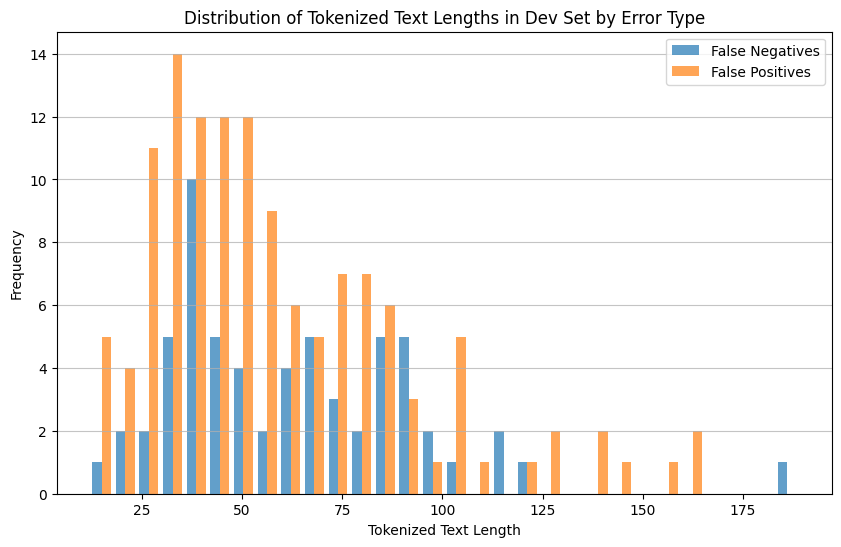

In [16]:
eadf = df_dev.copy()
eadf.loc[(eadf["label"] == 1) & (eadf["correct"] == 0), "error_type"] = "FN"
eadf.loc[(eadf["label"] == 0) & (eadf["correct"] == 0), "error_type"] = "FP"
eadf = eadf.dropna(subset=["error_type"])
eadf["text_len"] = eadf["text"].map(lambda t: len(tokenizer(t, add_special_tokens=True, truncation=False)["input_ids"]))
plt.figure(figsize=(10, 6))
plt.hist(eadf.groupby("error_type")["text_len"].apply(list), bins=30, alpha=0.7)
plt.title("Distribution of Tokenized Text Lengths in Dev Set by Error Type")
plt.xlabel("Tokenized Text Length")
plt.ylabel("Frequency")
plt.legend(["False Negatives", "False Positives"])
plt.grid(axis="y", alpha=0.75)
plt.show()

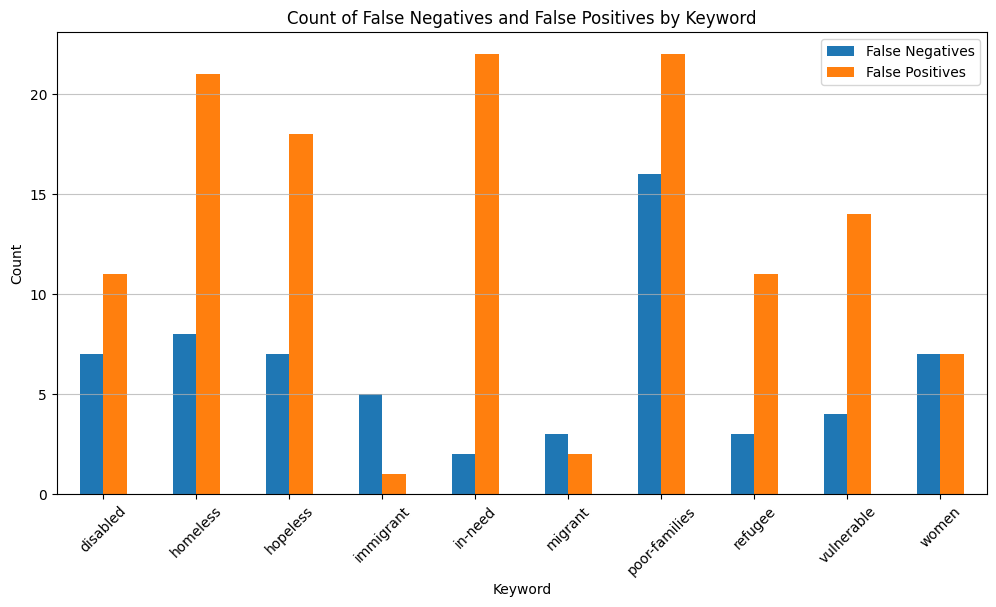

In [17]:
eadf.pivot_table(columns="error_type", index="keyword", values="text_len", aggfunc="count").plot(kind="bar", figsize=(12, 6))
plt.title("Count of False Negatives and False Positives by Keyword")
plt.xlabel("Keyword")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.legend(["False Negatives", "False Positives"])
plt.grid(axis="y", alpha=0.75)
plt.show()

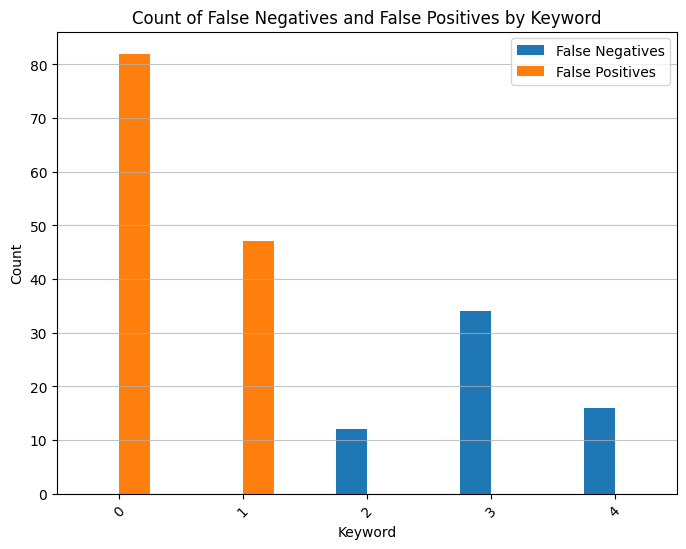

In [18]:
eadf.pivot_table(columns="error_type", index="orig_label", values="text_len", aggfunc="count").plot(kind="bar", figsize=(8, 6))
plt.title("Count of False Negatives and False Positives by Keyword")
plt.xlabel("Keyword")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.legend(["False Negatives", "False Positives"])
plt.grid(axis="y", alpha=0.75)
plt.show()

<Axes: xlabel='pred_prob', ylabel='orig_label'>

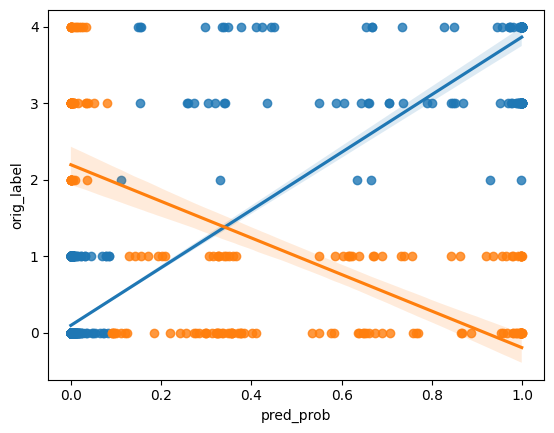

In [19]:
import seaborn as sns
sns.regplot(x=df_dev.loc[df_dev["correct"]==1]["pred_prob"], y=df_dev.loc[df_dev["correct"]==1]["orig_label"])
sns.regplot(x=df_dev.loc[df_dev["correct"]==0]["pred_prob"], y=df_dev.loc[df_dev["correct"]==0]["orig_label"])

         keyword  gold_pos  gold_neg  FN  FP   FN_rate   FP_rate
0       disabled        14       180   7  11  0.500000  0.061111
1       homeless        29       183   8  21  0.275862  0.114754
2       hopeless        26       191   7  18  0.269231  0.094241
3      immigrant         7       211   5   1  0.714286  0.004739
4        in-need        33       193   2  22  0.060606  0.113990
5        migrant         5       202   3   2  0.600000  0.009901
6  poor-families        38       152  16  22  0.421053  0.144737
7        refugee        13       175   3  11  0.230769  0.062857
8     vulnerable        20       189   4  14  0.200000  0.074074
9          women        14       219   7   7  0.500000  0.031963


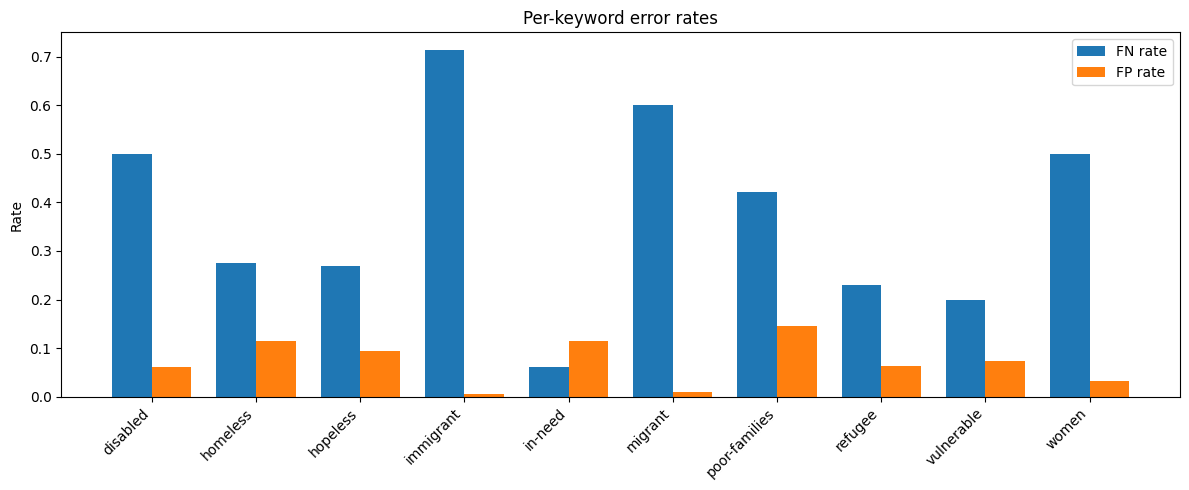

In [20]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

threshold = best_t

dev_eval = df_dev.copy().reset_index(drop=True)
dev_eval["pred"] = (dev_eval["pred_prob"] >= threshold).astype(int)

rows = []

for kw, g in dev_eval.groupby("keyword"):
    gold_pos = (g["label"] == 1).sum()
    gold_neg = (g["label"] == 0).sum()

    fn = ((g["label"] == 1) & (g["pred"] == 0)).sum()
    fp = ((g["label"] == 0) & (g["pred"] == 1)).sum()

    rows.append({
        "keyword": kw,
        "gold_pos": gold_pos,
        "gold_neg": gold_neg,
        "FN": fn,
        "FP": fp,
        "FN_rate": fn / gold_pos if gold_pos > 0 else np.nan,
        "FP_rate": fp / gold_neg if gold_neg > 0 else np.nan,
    })

kw_rates = pd.DataFrame(rows).sort_values("keyword").reset_index(drop=True)

print(kw_rates)

x = np.arange(len(kw_rates))
width = 0.38

plt.figure(figsize=(12, 5))
plt.bar(x - width/2, kw_rates["FN_rate"], width, label="FN rate")
plt.bar(x + width/2, kw_rates["FP_rate"], width, label="FP rate")

plt.xticks(x, kw_rates["keyword"], rotation=45, ha="right")
plt.ylabel("Rate")
plt.title("Per-keyword error rates")
plt.legend()
plt.tight_layout()
plt.show()

   orig_label  gold_pos  gold_neg  FN  FP   FN_rate   FP_rate
0           0         0      1704   0  82       NaN  0.048122
1           1         0       191   0  47       NaN  0.246073
2           2        18         0  12   0  0.666667       NaN
3           3        89         0  34   0  0.382022       NaN
4           4        92         0  16   0  0.173913       NaN


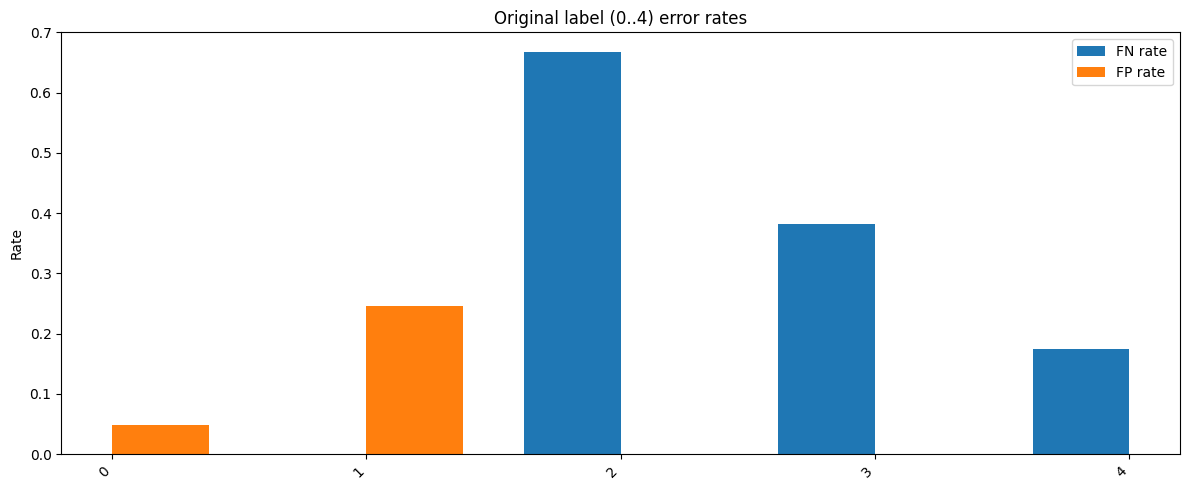

In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

threshold = best_t

dev_eval = df_dev.copy().reset_index(drop=True)
dev_eval["pred"] = (dev_eval["pred_prob"] >= threshold).astype(int)

rows = []

for kw, g in dev_eval.groupby("orig_label"):
    gold_pos = (g["label"] == 1).sum()
    gold_neg = (g["label"] == 0).sum()

    fn = ((g["label"] == 1) & (g["pred"] == 0)).sum()
    fp = ((g["label"] == 0) & (g["pred"] == 1)).sum()

    rows.append({
        "orig_label": kw,
        "gold_pos": gold_pos,
        "gold_neg": gold_neg,
        "FN": fn,
        "FP": fp,
        "FN_rate": fn / gold_pos if gold_pos > 0 else np.nan,
        "FP_rate": fp / gold_neg if gold_neg > 0 else np.nan,
    })

kw_rates = pd.DataFrame(rows).sort_values("orig_label").reset_index(drop=True)

print(kw_rates)

x = np.arange(len(kw_rates))
width = 0.38

plt.figure(figsize=(12, 5))
plt.bar(x - width/2, kw_rates["FN_rate"], width, label="FN rate")
plt.bar(x + width/2, kw_rates["FP_rate"], width, label="FP rate")

plt.xticks(x, kw_rates["orig_label"], rotation=45, ha="right")
plt.ylabel("Rate")
plt.title("Original label (0..4) error rates")
plt.legend()
plt.tight_layout()
plt.show()

<Axes: xlabel='orig_label'>

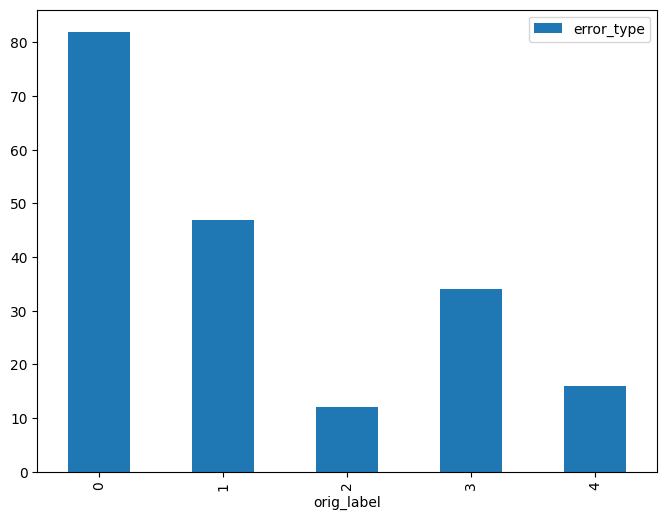

In [22]:
eadf.pivot_table(index="orig_label", values="error_type", aggfunc="count").plot(kind="bar", figsize=(8, 6))

Errors by confidence bin:
conf_bin
0.50-0.60     6
0.60-0.70    17
0.70-0.80     7
0.80-0.90     5
0.90-1.00    99
dtype: int64

False positives by confidence bin:
conf_bin
0.50-0.60     6
0.60-0.70    17
0.70-0.80     7
0.80-0.90     5
0.90-1.00    37
dtype: int64

False negatives by confidence bin:
conf_bin
0.50-0.60     0
0.60-0.70     0
0.70-0.80     0
0.80-0.90     0
0.90-1.00    62
dtype: int64


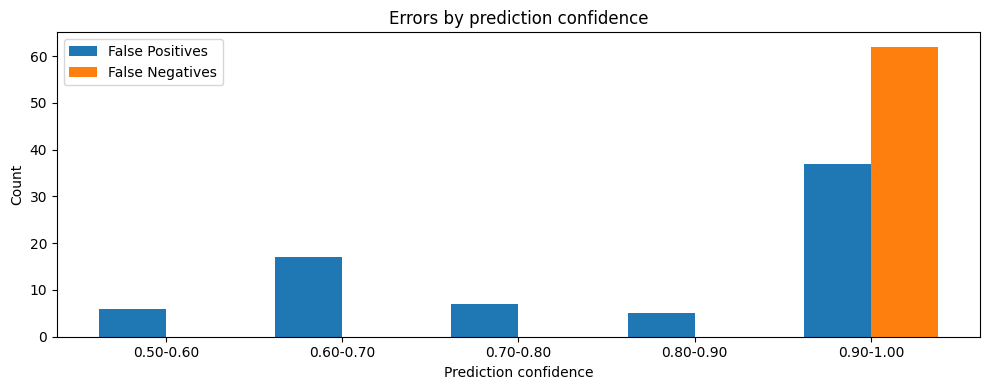

 par_id       keyword  label  pred  pred_prob  pred_conf                                                                                                                                                                                                                                                                                                                                                                                                                          text
   6234 poor-families      1     0   0.000456   0.999544                                                                                                                                                                                                             The World Health Organization did not give a reason for the increase in deaths , but a provincial health official in Sindh said that the disease hit areas where poor families did not vaccinate their children .
   7414      disabled      1     0   0.000457   0.999543  

In [23]:
dev_eval["pred"] = (dev_eval["pred_prob"] >= threshold).astype(int)
dev_eval["error"] = (dev_eval["pred"] != dev_eval["label"]).astype(int)

# Confidence in the predicted class
dev_eval["pred_conf"] = np.where(
    dev_eval["pred"] == 1,
    dev_eval["pred_prob"],
    1.0 - dev_eval["pred_prob"]
)

# Keep only mistakes
err = dev_eval[dev_eval["error"] == 1].copy()

# Bucket error confidence
bins = [0.50, 0.60, 0.70, 0.80, 0.90, 1.000001]
labels = ["0.50-0.60", "0.60-0.70", "0.70-0.80", "0.80-0.90", "0.90-1.00"]

err["conf_bin"] = pd.cut(err["pred_conf"], bins=bins, labels=labels, right=False)

# Count errors by confidence bin
err_counts = err.groupby("conf_bin").size().reindex(labels, fill_value=0)
print("Errors by confidence bin:")
print(err_counts)

# Separate FP / FN by confidence bin
fp_counts = err[err["pred"] == 1].groupby("conf_bin").size().reindex(labels, fill_value=0)
fn_counts = err[err["pred"] == 0].groupby("conf_bin").size().reindex(labels, fill_value=0)

print("\nFalse positives by confidence bin:")
print(fp_counts)

print("\nFalse negatives by confidence bin:")
print(fn_counts)

# Plot
x = np.arange(len(labels))
width = 0.38

plt.figure(figsize=(10, 4))
plt.bar(x - width/2, fp_counts.values, width, label="False Positives")
plt.bar(x + width/2, fn_counts.values, width, label="False Negatives")

plt.xticks(x, labels)
plt.xlabel("Prediction confidence")
plt.ylabel("Count")
plt.title("Errors by prediction confidence")
plt.legend()
plt.tight_layout()
plt.show()

cols = ["par_id", "keyword", "label", "pred", "pred_prob", "pred_conf"]
extra_cols = [c for c in ["text", "paragraph"] if c in err.columns]  # use whichever text column you have
cols = cols + extra_cols

top_bad = err.sort_values("pred_conf", ascending=False).head(10)
print(top_bad[cols].to_string(index=False))

In [24]:
df_dev

,par_id,doc_id,keyword,country,text,label,orig_label,label_vec,pred,correct,pred_prob
0,4046,@@14767805,hopeless,us,We also know that they can benefit by receivin...,1,3,"[1.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0]",0,0,0.001397
1,1279,@@7896098,refugee,ng,Pope Francis washed and kissed the feet of Mus...,1,4,"[0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0]",1,1,0.997832
2,8330,@@17252299,refugee,ng,Many refugees do n't want to be resettled anyw...,1,2,"[0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0]",0,0,0.000863
3,4063,@@3002894,in-need,ie,"""Budding chefs , like """" Fred """" , """" Winston ...",1,4,"[1.0, 0.0, 0.0, 1.0, 1.0, 1.0, 0.0]",1,1,0.997853
4,4089,@@25597822,homeless,pk,"""In a 90-degree view of his constituency , one...",1,3,"[1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]",0,0,0.033562
...,...,...,...,...,...,...,...,...,...,...,...
2089,10462,@@22092971,homeless,gh,"The sad spectacle , which occurred on Saturday...",0,0,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]",0,1,0.000524
2090,10463,@@4676355,refugee,pk,""""""" The Pakistani police came to our house and...",0,0,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]",0,1,0.000555
2091,10464,@@19612634,disabled,ie,"""When Marie O'Donoghue went looking for a spec...",0,0,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]",0,1,0.000670
2092,10465,@@14297363,women,lk,"""Sri Lankan norms and culture inhibit women fr...",0,1,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]",0,1,0.002449


In [25]:
dev_split

,par_id,label,label_vec
0,4046,"[1, 0, 0, 1, 0, 0, 0]","[1.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0]"
1,1279,"[0, 1, 0, 0, 0, 0, 0]","[0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0]"
2,8330,"[0, 0, 1, 0, 0, 0, 0]","[0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0]"
3,4063,"[1, 0, 0, 1, 1, 1, 0]","[1.0, 0.0, 0.0, 1.0, 1.0, 1.0, 0.0]"
4,4089,"[1, 0, 0, 0, 0, 0, 0]","[1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]"
...,...,...,...
2089,10462,"[0, 0, 0, 0, 0, 0, 0]","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]"
2090,10463,"[0, 0, 0, 0, 0, 0, 0]","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]"
2091,10464,"[0, 0, 0, 0, 0, 0, 0]","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]"
2092,10465,"[0, 0, 0, 0, 0, 0, 0]","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]"
